# Importing libs

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Loading csv files

In [2]:
train_df = pd.read_csv('../datasets/PAD/train_metadata.csv')
validation_df = pd.read_csv('../datasets/PAD/validation_metadata.csv')
test_df = pd.read_csv('../datasets/PAD/test_metadata.csv')

# Visualizing the splits and the class balance

## Visualizing in each split

In [ ]:
def print_class_distribution(df, name):
    counts = df['benign_malignant'].value_counts()
    return counts

In [ ]:
def plot_class_distribution(counts, split_name):
    labels = counts.index.tolist()
    values = counts.values
    percentages = (counts / counts.sum()) * 100

    plt.figure(figsize=(6,4))
    bars = plt.bar(labels, values, color=['skyblue', 'salmon'])
    
    plt.ylim(0, max(values) * 1.1)

    for bar, value, pct in zip(bars, values, percentages):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + max(values)*0.01,
                 f"{value} ({pct:.1f}%)", ha='center', va='bottom', fontsize=10)

    plt.title(f'Class distribution - {split_name}')
    plt.ylabel('Number of samples')
    plt.xlabel('Class')
    plt.show()

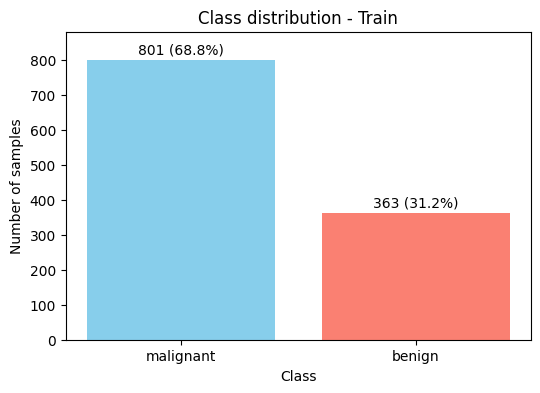

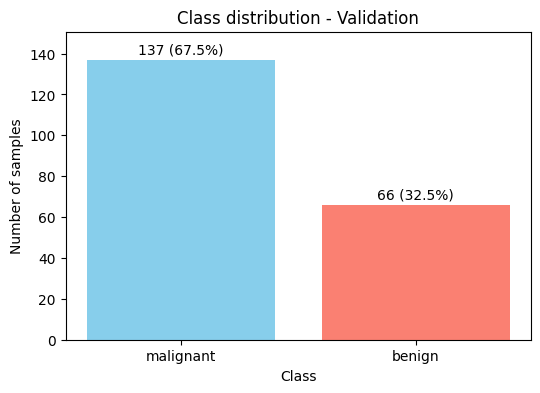

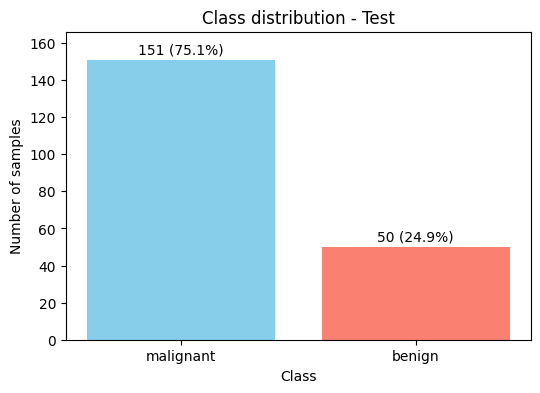

In [ ]:
train_counts = print_class_distribution(train_df, "Train")
val_counts = print_class_distribution(validation_df, "Validation")
test_counts = print_class_distribution(test_df, "Test")

train_count = len(train_df)
val_count = len(validation_df)
test_count = len(test_df)
total_count = train_count + val_count + test_count

plot_class_distribution(train_counts, "Train")
plot_class_distribution(val_counts, "Validation")
plot_class_distribution(test_counts, "Test")

## Visualizing the partition balance

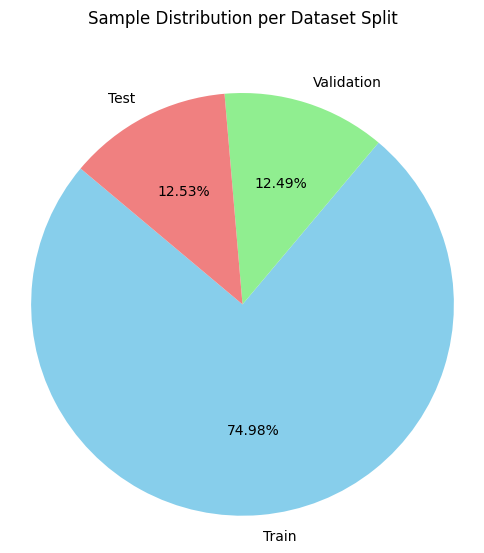


Total number of samples per split:
Train: 1723
Validation: 287
Test: 288


In [ ]:
split_labels = ['Train', 'Validation', 'Test']
split_counts = [train_count, val_count, test_count]

plt.figure(figsize=(6, 6))
plt.pie(
    split_counts,
    labels=split_labels,
    autopct='%1.2f%%',
    colors=['skyblue', 'lightgreen', 'lightcoral'],
    startangle=140
)
plt.title('Sample Distribution per Dataset Split\n\n')
plt.axis('equal')
plt.show()

print("\nTotal number of samples per split:")
print(f"Train: {train_count}")
print(f"Validation: {val_count}")
print(f"Test: {test_count}")

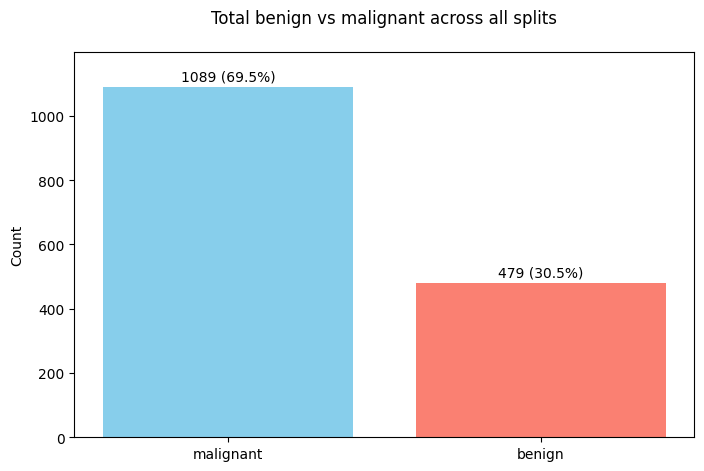

In [ ]:
total_counts = train_counts.add(val_counts, fill_value=0).add(test_counts, fill_value=0).astype(int)
total_percentages = (total_counts / total_counts.sum()) * 100

labels = total_counts.index.tolist()
counts = total_counts.values
percentages = total_percentages.values

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, counts, color=['skyblue', 'salmon'])

plt.ylim(0, max(counts) * 1.1)

for bar, count, pct in zip(bars, counts, percentages):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + max(counts)*0.01,
             f"{count} ({pct:.1f}%)",
             ha='center', va='bottom', fontsize=10)

plt.title("Total benign vs malignant across all splits\n")
plt.ylabel("Count")
plt.show()